# Prediction House Price with Linear Regression

**Objective:** Build and evaluate a Linear Regression model to predict house prices using property characteristics such as area, rooms, location, condition, garage avaibility and house age.




## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option("display.max_columns", None)


## 2. Load Dataset

In [2]:
# If your CSV is in the same folder as this notebook, use:
DATA_PATH = "House Price Prediction Dataset (1).csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (2000, 10)


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


## 3. Exploratory Data Analysis (EDA)

In [3]:
print("Data types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe(include="all").T)


Data types:


Id            int64
Area          int64
Bedrooms      int64
Bathrooms     int64
Floors        int64
YearBuilt     int64
Location     object
Condition    object
Garage       object
Price         int64
dtype: object


Missing values:


Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


Duplicate rows: 0

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,2000.0,NaN,NaN,NaN,1000.5,577.494589,1.0,500.75,1000.5,1500.25,2000.0
Area,2000.0,NaN,NaN,NaN,2786.2095,1295.146799,501.0,1653.0,2833.0,3887.5,4999.0
Bedrooms,2000.0,NaN,NaN,NaN,3.0035,1.424606,1.0,2.0,3.0,4.0,5.0
Bathrooms,2000.0,NaN,NaN,NaN,2.5525,1.10899,1.0,2.0,3.0,4.0,4.0
Floors,2000.0,NaN,NaN,NaN,1.9935,0.809188,1.0,1.0,2.0,3.0,3.0
YearBuilt,2000.0,NaN,NaN,NaN,1961.446,35.926695,1900.0,1930.0,1961.0,1993.0,2023.0
Location,2000,4,Downtown,558,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Condition,2000,4,Fair,521,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Garage,2000,2,No,1038,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,2000.0,NaN,NaN,NaN,537676.855,276428.845719,50005.0,300098.0,539254.0,780086.0,999656.0


In [ ]:
#insight
there is no null nalues and duplicates in this dataset


Location distribution:


Location
Downtown    558
Urban       485
Suburban    483
Rural       474
Name: count, dtype: int64


Condition distribution:


Condition
Fair         521
Excellent    511
Poor         507
Good         461
Name: count, dtype: int64


Garage distribution:


Garage
No     1038
Yes     962
Name: count, dtype: int64

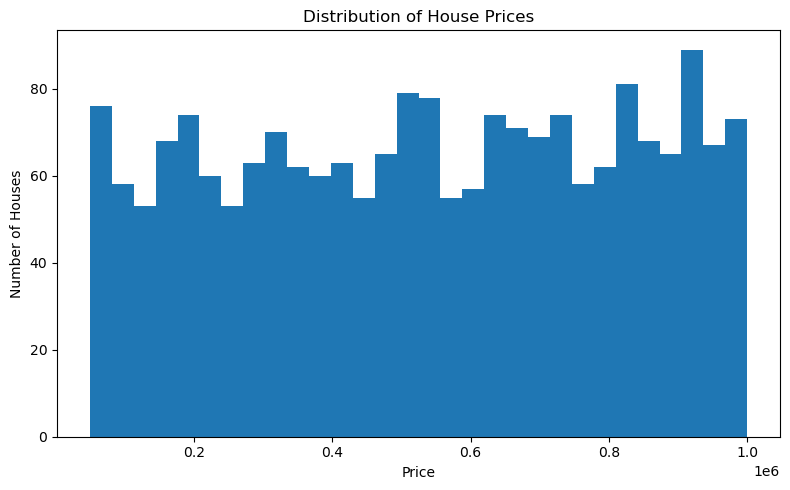

In [4]:
# Categorical distributions
for col in ["Location", "Condition", "Garage"]:
    print(f"\n{col} distribution:")
    display(df[col].value_counts())

# Target distribution
plt.figure(figsize=(8, 5))
plt.hist(df["Price"], bins=30)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.show()


## 4. Feature Selection Discussion

The target variable is **`Price`**.

Useful candidate predictors are:
- **Area:** larger properties may have higher prices.
- **Bedrooms / Bathrooms:** represent size and utility.
- **Floors:** may capture property structure.
- **Location:** different locations can have different market values.
- **Condition:** property condition may affect price.
- **Garage:** garage availability can influence value.
- **HouseAge:** derived from `YearBuilt`; older properties may have different pricing.

`Id` is excluded because it is only an identifier and has no meaningful business interpretation.

`YearBuilt` is replaced by `HouseAge` to make the feature easier to interpret. We do not keep both because `HouseAge = 2026 - YearBuilt`, which would introduce perfect linear redundancy.


## 5. Feature Engineering and Preprocessing

In [5]:
data = df.copy()

# Create an interpretable age feature.
REFERENCE_YEAR = 2026
data["HouseAge"] = REFERENCE_YEAR - data["YearBuilt"]

# Remove identifier, original year, and target from the feature matrix.
X = data.drop(columns=["Price", "Id", "YearBuilt"])
y = data["Price"]

numeric_features = X.select_dtypes(exclude="object").columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'HouseAge']
Categorical features: ['Location', 'Condition', 'Garage']


In [6]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), numeric_features),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
    ]), categorical_features)
])

print("Preprocessing pipeline created successfully.")


Preprocessing pipeline created successfully.


## 6. Correlation Analysis

Price        1.000000
Floors       0.055890
YearBuilt    0.004845
Area         0.001542
Bedrooms    -0.003471
HouseAge    -0.004845
Bathrooms   -0.015737
Id          -0.025643
Name: Price, dtype: float64

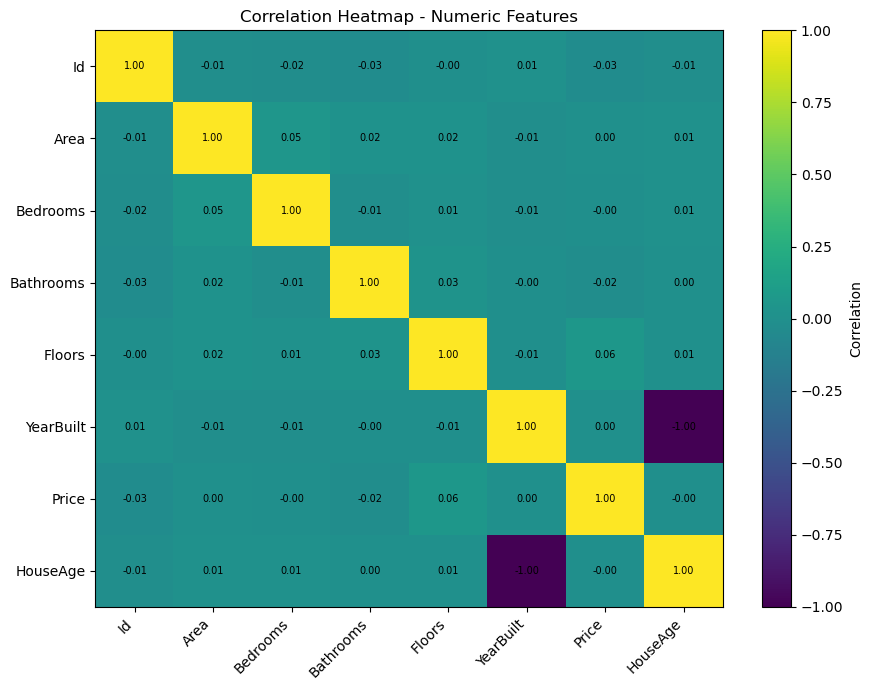

In [7]:
corr = data.select_dtypes(include=np.number).corr()

display(corr["Price"].sort_values(ascending=False))

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap - Numeric Features")

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()


### Correlation finding

In this dataset, the numeric variables have **very weak linear correlation with `Price`**. `Floors` has the largest positive numeric correlation, but it is still small. This is an important finding: the dataset does not contain a strong linear relationship between the available numeric variables and house price.

Categorical variables are handled separately through One-Hot Encoding and therefore are not represented in the numeric correlation matrix above.


## 7. Train-Test Split (80/20)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 1600
Testing rows: 400


## 8. Train Linear Regression Model

In [9]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)

print("Linear Regression model trained successfully.")


Linear Regression model trained successfully.


## 9. Model Evaluation

In [10]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"MAE  : {mae:,.2f}")
print(f"R²   : {r2:.4f}")


MSE  : 78,321,466,146.03
RMSE : 279,859.73
MAE  : 243,241.98
R²   : -0.0067


### Metric interpretation

- **MSE:** average squared prediction error; lower is better.
- **RMSE:** error expressed in the same units as house price; lower is better.
- **MAE:** average absolute prediction error; lower is better.
- **R²:** proportion of target variance explained by the model. A value close to 1 is strong, while a value near 0 means the model explains little of the variation. A negative value means the model performs worse than a simple mean-price baseline on the test set.


## 10. Actual vs Predicted Price

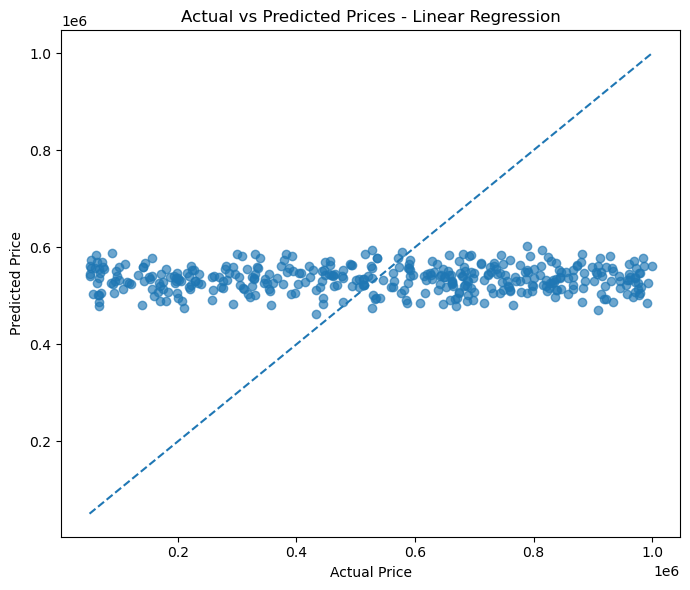

In [11]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.65)

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, linestyle="--")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices - Linear Regression")
plt.tight_layout()
plt.show()


The ideal result would show points concentrated around the diagonal line. In this dataset, the points are widely scattered, which is consistent with the low/negative R² score and indicates weak predictive performance.


## 11. Residual Analysis

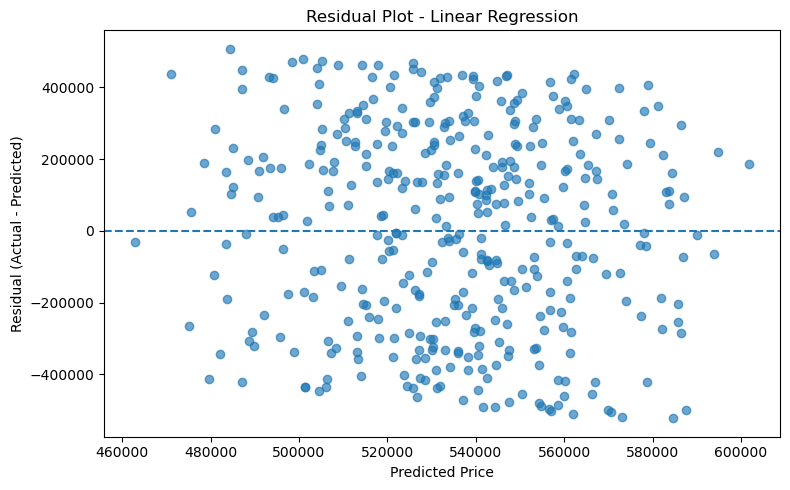

Residual mean: 8623.215367676816


In [12]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.65)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot - Linear Regression")
plt.tight_layout()
plt.show()

print("Residual mean:", residuals.mean())


A good regression model generally has residuals scattered around zero without a strong systematic pattern. Here, the residuals are large, reflecting substantial unexplained variation in the target.


## 12. Coefficient Analysis

,Feature,Coefficient,Absolute_Coefficient
8,cat__Condition_Fair,24083.307846,24083.307846
3,num__Floors,23727.983633,23727.983633
9,cat__Condition_Good,-12941.044835,12941.044835
7,cat__Location_Urban,-12718.918912,12718.918912
6,cat__Location_Suburban,11511.989815,11511.989815
2,num__Bathrooms,-9662.248234,9662.248234
10,cat__Condition_Poor,4073.268930,4073.268930
11,cat__Garage_Yes,2373.530579,2373.530579
5,cat__Location_Rural,1317.542020,1317.542020
4,num__HouseAge,-117.613885,117.613885


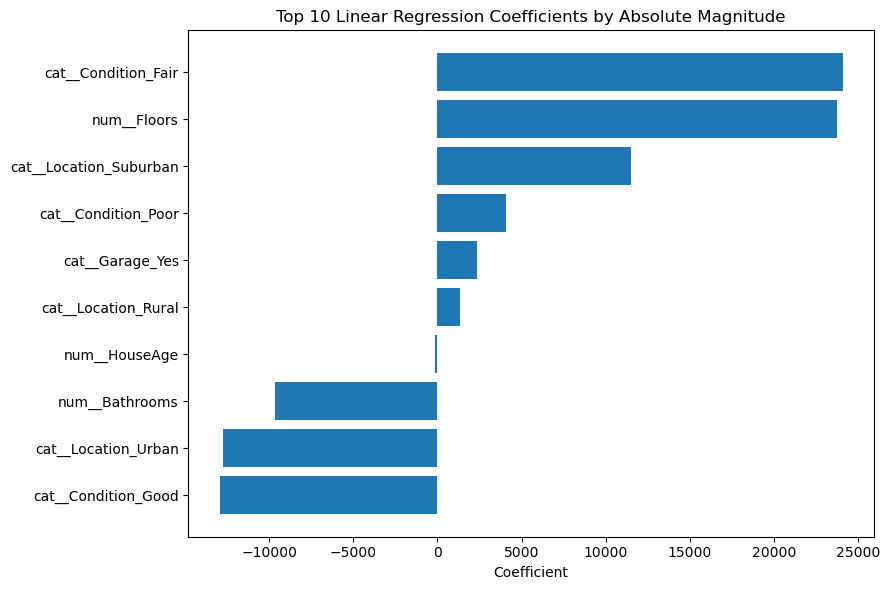

In [13]:
feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = linear_model.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Absolute_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Absolute_Coefficient", ascending=False)

display(coef_df.head(15))

top_coef = coef_df.head(10).sort_values("Coefficient")

plt.figure(figsize=(9, 6))
plt.barh(top_coef["Feature"], top_coef["Coefficient"])
plt.xlabel("Coefficient")
plt.title("Top 10 Linear Regression Coefficients by Absolute Magnitude")
plt.tight_layout()
plt.show()


### How to interpret coefficients

For numeric features, a coefficient represents the estimated change in price for a one-unit increase in that feature, holding the other model features constant.

For One-Hot encoded categorical features, a coefficient represents the estimated difference from the omitted reference category, holding other features constant.

Because the overall model has very weak predictive performance, coefficient magnitudes should be interpreted cautiously rather than treated as strong evidence of causal price effects.


# Bonus – Compare Linear Regression, Ridge and Lasso
Ridge and Lasso are regularized linear models.
They can help control large coefficients and reduce overfitting, especially when one-hot encoding creates many correlated features.



In [16]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=10.0),
    "Lasso": Lasso(alpha=500.0, max_iter=20000)
}

results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)

    mse_value = mean_squared_error(y_test, pred)
    rmse_value = np.sqrt(mse_value)
    r2_value = r2_score(y_test, pred)

    results.append({
        "Model": name,
        "MSE": mse_value,
        "RMSE": rmse_value,
        "R2": r2_value
    })

comparison = pd.DataFrame(results).sort_values("R2", ascending=False)
display(comparison)
    

,Model,MSE,RMSE,R2
2,Lasso,7.828135e+10,279788.047763,-0.006202
1,Ridge,7.831942e+10,279856.078631,-0.006692
0,Linear Regression,7.832147e+10,279859.725838,-0.006718


### Conclusion

1. The dataset contains **2,000 records and 10 original columns**.
2. There are **no missing values or duplicate rows** in the supplied data.
3. `Id` was excluded because it is an identifier.
4. `HouseAge` was engineered from `YearBuilt`.
5. `Location`, `Condition`, and `Garage` were encoded using One-Hot Encoding.
6. An 80/20 train-test split was used with `random_state=42`.
7. Linear Regression, Ridge, and Lasso were trained and evaluated.
8. Actual-vs-predicted and residual plots were used for diagnostics.
9. The model achieved a **negative R² on the test set**, showing that it performs worse than the mean-price baseline.
10. Correlation analysis also shows very weak relationships between the available numeric features and price.



